# Imports

In [18]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import glob

from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from IPython.display import display

# Configuration

In [19]:
import requests
topic_name = "aysel_tfe_server_9988" 

In [20]:
CURRENT_DATASET = "Flickr8k"
DATA_DIR = os.path.join(os.getcwd(), 'TFE_Data')

IMAGE_DIR = os.path.join(DATA_DIR, "Flickr8k", "Images", "Flicker8k_Dataset")
IMAGE_PATHS = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))

DIMENSIONS_TO_TEST = [512, 256, 128, 64, 32, 16]

sns.set_theme(style="whitegrid")
print(f"Target Dataset: {CURRENT_DATASET}")
print(f"Dimensions to test: {DIMENSIONS_TO_TEST}")

Target Dataset: Flickr8k
Dimensions to test: [512, 256, 128, 64, 32, 16]


# Data Loading

In [21]:
def load_raw_matrix(modality, model_name):
    """Loads a previously saved RAW embedding matrix."""
    file_path = os.path.join(DATA_DIR, f"X_{modality}_{model_name}_raw_{CURRENT_DATASET}.npy")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing matrix: {file_path}. Did you run Notebook 1 for {model_name}?")
    
    matrix = np.load(file_path)
    print(f"Loaded {modality.upper()} | Model: {model_name} | Shape: {matrix.shape}")
    return matrix

In [22]:
# Normalize vectors for Cosine Similarity (maps vectors to a unit sphere)
def normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # Avoid division by zero
    return matrix / np.where(norms == 0, 1e-9, norms)

# Dimensionality Reduction Engine

In [23]:
def apply_pca(raw_matrix, target_dim):
    """Applies Principal Component Analysis (Deterministic, preserves max variance)."""
    pca = PCA(n_components=target_dim)
    return pca.fit_transform(raw_matrix)

In [24]:
def apply_grp(raw_matrix, target_dim):
    """Applies Gaussian Random Projection (Stochastic, JL-Lemma distance preservation)."""
    grp = GaussianRandomProjection(n_components=target_dim)
    return grp.fit_transform(raw_matrix)

In [25]:
# Dictionary to store our available reduction methods
REDUCTION_PIPELINE = {
    "PCA": apply_pca,
    "GRP": apply_grp
    # You can easily add "SVD": apply_svd here later!
}

# Performance Metrics: Retrieval Engine

## Topological Neighborhood Preservation (TNP@k)

If we just compare a reduced image vector against the exact same reduced image vector, the similarity will always be 100% (an exact match). This won't show us any "drop" in performance.

Therefore, the scientifically correct way to evaluate dimensionality reduction on a single modality without labels is Neighborhood Preservation.

The Ground Truth: For a given image, what were its Top 5 most similar images in the heavy, 2048-dimensional RAW space?

The Test: After squeezing the vectors down to 64 dimensions, are those same 5 images still the closest?

If the reduction destroys information, the nearest neighbors will change, and the "Preservation Score" will drop.

To ensure the dimensionality reduction algorithms did not destroy the latent manifold, we calculate Topological Neighborhood Preservation (TNP@k). This metric measures the strict geometric overlap of the $k$-nearest neighbors between the high-dimensional and low-dimensional spaces, independent of localized rank permutations.

In [26]:
def evaluate_neighborhood_preservation(raw_sim_matrix, reduced_sim_matrix, k=5):
    """
    Evaluates how well the dimensionality reduction preserves the original geometric space.
    It checks how many of the original Top-K nearest neighbors are still in the new Top-K.
    """
    num_queries = raw_sim_matrix.shape[0]
    total_overlap_percentage = 0
    
    for i in range(num_queries):
        # np.argsort sorts ascending. 
        # The absolute closest item is always itself (index -1). 
        # So we take from -(k+1) up to -1 to get the actual Top K nearest neighbors.
        raw_top_k = set(np.argsort(raw_sim_matrix[i])[-(k+1):-1])
        red_top_k = set(np.argsort(reduced_sim_matrix[i])[-(k+1):-1])
        
        # Calculate how many neighbors remained the same
        overlap = len(raw_top_k.intersection(red_top_k))
        total_overlap_percentage += (overlap / k)
        
    # Return the average preservation score as a percentage
    return (total_overlap_percentage / num_queries) * 100

## Relative Mean Average Precision (Relative mAP@k)

While topological metrics evaluate pure geometric retention, they do not reflect the user experience of a search engine. Therefore, we calculate Relative Mean Average Precision (Relative mAP@k). Because our unimodal datasets lack explicit categorical labels, we utilize the top-K retrieval rankings of the uncompressed RAW vectors as a pseudo-ground truth. This allows us to measure how accurately the reduced vectors replicate the exact search results and ranking order of the original heavy architecture.

In [27]:
def evaluate_metrics(raw_sim, reduced_sim, gt_k=50, test_k=10):
    num_queries = raw_sim.shape[0]
    prec, rec, map_score = 0.0, 0.0, 0.0
    
    for i in range(num_queries):
        raw_ordered = np.argsort(raw_sim[i])[-(gt_k+1):-1][::-1]
        gt_set = set(raw_ordered)
        
        red_ordered = np.argsort(reduced_sim[i])[-(test_k+1):-1][::-1]
        retrieved_k = red_ordered[:test_k]
        
        hits = len(set(retrieved_k).intersection(gt_set))
        prec += hits / test_k
        rec += hits / gt_k
        
        ap, current_hits = 0.0, 0
        for rank, item_idx in enumerate(retrieved_k):
            if item_idx in gt_set:
                current_hits += 1
                ap += current_hits / (rank + 1.0)
        if len(gt_set) > 0:
            map_score += ap / min(len(gt_set), test_k)
            
    return {
        "Precision@10": (prec/num_queries)*100, 
        "Recall@10": (rec/num_queries)*100, 
        "mAP@10": (map_score/num_queries)*100
    }

# Green AI: Retrieval time analysis

In [28]:
def measure_retrieval_speed(matrix, num_trials=100):
    """Measures average milliseconds to query the entire database."""
    norm_mat = normalize_matrix(matrix)
    query = norm_mat[0].reshape(1, -1) # Random query
    
    start_time = time.perf_counter()
    for _ in range(num_trials):
        sims = cosine_similarity(query, norm_mat)
        _ = np.argsort(sims[0])[::-1]
    end_time = time.perf_counter()
    
    return ((end_time - start_time) / num_trials) * 1000

# XAI: Visualiser

In [29]:
def xai_visualize_reduction(raw_matrix, raw_sim, query_index=42, target_dim=32, top_k=5, reducer_name="PCA"):
    print(f"Generating XAI Visualizer ({reducer_name}-{target_dim})")
    
    reduction_func = apply_pca if reducer_name == "PCA" else apply_grp
    reduced_matrix = reduction_func(raw_matrix, target_dim)
    
    query_reduced = reduced_matrix[query_index].reshape(1, -1)
    sims_reduced = cosine_similarity(query_reduced, reduced_matrix)[0]
    
    top_indices_raw = raw_sim[query_index].argsort()[-(top_k+1):][::-1][1:]
    top_indices_reduced = sims_reduced.argsort()[-(top_k+1):][::-1][1:]
    
    fig, axes = plt.subplots(2, top_k + 1, figsize=(15, 5))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    query_img = Image.open(IMAGE_PATHS[query_index]).convert('RGB')
    axes[0, 0].imshow(query_img); axes[0, 0].set_title("QUERY (RAW)", fontweight="bold"); axes[0, 0].axis("off")
    axes[1, 0].imshow(query_img); axes[1, 0].set_title(f"QUERY ({reducer_name}-{target_dim})", fontweight="bold"); axes[1, 0].axis("off")
    
    for i, idx in enumerate(top_indices_raw):
        axes[0, i+1].imshow(Image.open(IMAGE_PATHS[idx]).convert('RGB'))
        axes[0, i+1].set_title(f"RAW Rank {i+1}\nSim: {raw_sim[query_index][idx]:.2f}", fontsize=9)
        axes[0, i+1].axis("off")
        
    for i, idx in enumerate(top_indices_reduced):
        border_color = "green" if idx in top_indices_raw else "red"
        match_text = "(MATCH)" if idx in top_indices_raw else "(NEW)"
        axes[1, i+1].imshow(Image.open(IMAGE_PATHS[idx]).convert('RGB'))
        axes[1, i+1].set_title(f"Rank {i+1} {match_text}\nSim: {sims_reduced[idx]:.2f}", fontsize=9, color=border_color)
        axes[1, i+1].axis("off")
        
    plt.show()

# Experiment

In [30]:
def run_experiment(modality, model_name):
    print(f"\n--- Running Unified Pipeline for {model_name.upper()} ({modality}) ---")
    
    # 1. Load RAW matrix and calculate baselines
    raw_matrix = load_raw_matrix(modality, model_name)
    max_dim = raw_matrix.shape[1]
    
    raw_norm = normalize_matrix(raw_matrix)
    raw_sim = cosine_similarity(raw_norm, raw_norm)
    raw_speed_ms = measure_retrieval_speed(raw_matrix)
    
    # The Baseline (RAW) record
    master_results = [{
        "Model": model_name, "Method": "RAW (Baseline)", "Dim": max_dim,
        "Preservation@5": 100.00,
        "mAP@10": 100.00, "Prec@10": 100.00, "Rec@10": 100.00,
        "Time (ms)": raw_speed_ms, "Speedup": "1.0x"
    }]
    
    # 2. Exhaustive Loop over Reducers and Dimensions
    for method_name, reduction_func in REDUCTION_PIPELINE.items():
        for dim in DIMENSIONS_TO_TEST:
            if dim >= max_dim: continue
            
            # --- A. REDUCE ---
            reduced_matrix = reduction_func(raw_matrix, dim)
            red_norm = normalize_matrix(reduced_matrix)
            red_sim = cosine_similarity(red_norm, red_norm)
            
            # --- B. SAVE ---
            save_path = os.path.join(DATA_DIR, f"X_{modality}_{model_name}_{method_name.lower()}_{dim}_{CURRENT_DATASET}.npy")
            np.save(save_path, reduced_matrix)
            print(f"Saved: {save_path}")
            
            # --- C. EVALUATE ---
            speed_ms = measure_retrieval_speed(reduced_matrix)
            speedup = raw_speed_ms / speed_ms if speed_ms > 0 else 0
            
            metrics = evaluate_metrics(raw_sim, red_sim)
            preservation = evaluate_neighborhood_preservation(raw_sim, red_sim, k=5)
            
            # --- D. LOG ---
            master_results.append({
                "Model": model_name, "Method": method_name, "Dim": dim,
                "Preservation@5": round(preservation, 2),
                "mAP@10": metrics["mAP@10"], "Prec@10": metrics["Precision@10"], 
                "Rec@10": metrics["Recall@10"],
                "Time (ms)": speed_ms, "Speedup": f"{speedup:.1f}x"
            })
            
    df = pd.DataFrame(master_results).round(2)
    display(df)
    
    return df

# Execution

In [31]:

def plot_unimodal_results(df, modality, model_name):
    """Generates and saves the 'Elbow' plot for a specific model."""
    plt.figure(figsize=(8, 5))
    
    line_data = df[df["Method"] != "RAW (Baseline)"]
    sns.lineplot(data=line_data, x="Dim", y="Preservation@5", hue="Method", marker="o", linewidth=2.5)    
    
    plt.axhline(y=100.0, color='red', linestyle='--', label='RAW Baseline (100%)')
    
    task_name = "CBIR (Image-to-Image)" if modality == "vision" else "T2T (Text-to-Text)"
    plt.title(f"{model_name.upper()} Dimensionality Reduction Impact\nTask: {task_name}", fontsize=12, fontweight='bold')
    plt.xlabel("Vector Dimension (Log Scale)", fontsize=10)
    plt.ylabel("Neighborhood Preservation@5 (%)", fontsize=10)
    plt.xscale('log', base=2)
    plt.xticks(DIMENSIONS_TO_TEST, labels=DIMENSIONS_TO_TEST)
    plt.legend(title="Method")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, f"plot_unimodal_{modality}_{model_name}.png"), dpi=300)
    plt.show()

In [39]:
def plot_unimodal_grid(master_df, modality):
    """
    Takes a combined dataframe of multiple models and plots them in a neat grid.
    """
    print(f"\nGenerating Subplot Grid for {modality.upper()} models...")
    
    # Filter out the RAW baseline so it doesn't skew the lines
    plot_df = master_df[master_df["Method"] != "RAW (Baseline)"]
    
    # Create the grid! col="Model" tells Seaborn to make a new subplot for each model.
    # col_wrap=3 means it will put a maximum of 3 plots per row.
    g = sns.relplot(
        data=plot_df, 
        x="Dim", y="Preservation@5", 
        hue="Method", col="Model", 
        kind="line", marker="o", linewidth=2.5,
        col_wrap=3, height=4, aspect=1.2, palette="Set1"
    )
    
    # Formatting the grid
    g.set_titles("{col_name} Architecture", fontweight='bold')
    g.set_axis_labels("Vector Dimension (Log Scale)", "Neighborhood Preservation@5 (%)")
    g.set(xscale="log")
    
    # Add the 100% baseline and gridlines to every single subplot
    for ax in g.axes.flat:
        ax.axhline(100.0, color='red', linestyle='--', alpha=0.6, label='RAW Baseline')
        ax.set_xticks(DIMENSIONS_TO_TEST)
        ax.set_xticklabels(DIMENSIONS_TO_TEST)
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
    # Main Title
    plt.suptitle(f"{modality.upper()} Models: Dimensionality Reduction Impact", y=1.05, fontsize=16, fontweight='bold')
    
    # Save and display
    plt.savefig(os.path.join(DATA_DIR, f"plot_grid_subplots_{modality}.png"), dpi=300, bbox_inches='tight')
    plt.show()

In [32]:
VISION_MODELS = ["resnet50", "mobilenet_v3", "vit", "deit", "clip_vision"]
TEXT_MODELS = ["rnn", "bert", "roberta", "gpt2", "clip_text"]

STARTING VISION (CBIR) EVALUATIONS

--- Running Unified Pipeline for RESNET50 (vision) ---
Loaded VISION | Model: resnet50 | Shape: (2000, 2048)
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_resnet50_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,resnet50,RAW (Baseline),2048,100.00,100.00,100.00,100.00,5.80,1.0x
1,resnet50,PCA,512,80.61,98.41,98.67,19.73,1.33,4.4x
2,resnet50,PCA,256,77.21,97.53,97.94,19.59,1.16,5.0x
3,resnet50,PCA,128,70.61,96.05,96.74,19.35,0.54,10.7x
4,resnet50,PCA,64,61.85,92.51,93.88,18.78,0.70,8.3x
5,resnet50,PCA,32,49.13,84.08,87.39,17.48,0.55,10.6x
6,resnet50,PCA,16,34.22,67.52,74.57,14.91,0.48,12.1x
7,resnet50,GRP,512,74.42,99.12,99.30,19.86,1.31,4.4x
8,resnet50,GRP,256,65.63,95.74,96.68,19.33,0.86,6.8x
9,resnet50,GRP,128,54.22,86.42,89.47,17.89,0.55,10.6x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,resnet50,RAW (Baseline),2048,100.00,100.00,100.00,100.00,5.80,1.0x
1,resnet50,PCA,512,80.61,98.41,98.67,19.73,1.33,4.4x
2,resnet50,PCA,256,77.21,97.53,97.94,19.59,1.16,5.0x
3,resnet50,PCA,128,70.61,96.05,96.74,19.35,0.54,10.7x
4,resnet50,PCA,64,61.85,92.51,93.88,18.78,0.70,8.3x
5,resnet50,PCA,32,49.13,84.08,87.39,17.48,0.55,10.6x
6,resnet50,PCA,16,34.22,67.52,74.57,14.91,0.48,12.1x
7,resnet50,GRP,512,74.42,99.12,99.30,19.86,1.31,4.4x
8,resnet50,GRP,256,65.63,95.74,96.68,19.33,0.86,6.8x
9,resnet50,GRP,128,54.22,86.42,89.47,17.89,0.55,10.6x


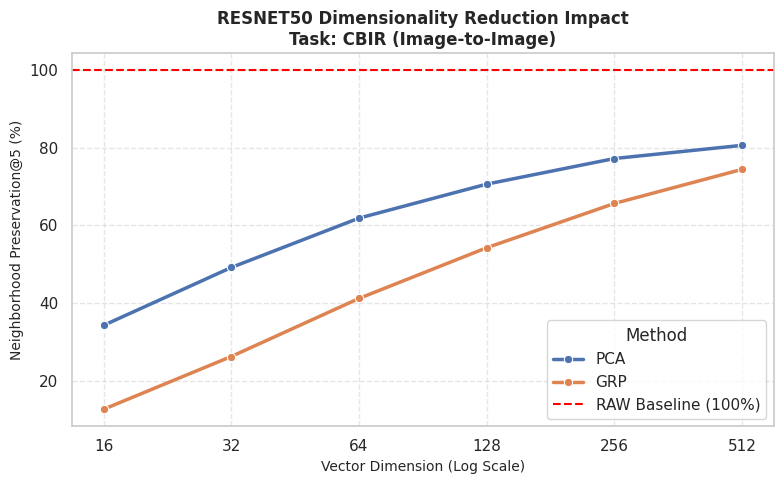


--- Running Unified Pipeline for MOBILENET_V3 (vision) ---
Loaded VISION | Model: mobilenet_v3 | Shape: (2000, 1024)
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_mobilenet_v3_grp_16_F

,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,mobilenet_v3,RAW (Baseline),1024,100.00,100.00,100.00,100.00,2.84,1.0x
1,mobilenet_v3,PCA,512,82.57,99.83,99.85,19.97,1.41,2.0x
2,mobilenet_v3,PCA,256,79.19,99.64,99.69,19.94,0.90,3.2x
3,mobilenet_v3,PCA,128,74.21,98.97,99.16,19.83,0.60,4.7x
4,mobilenet_v3,PCA,64,64.53,96.25,97.12,19.42,0.64,4.4x
5,mobilenet_v3,PCA,32,50.73,87.70,90.77,18.15,0.56,5.1x
6,mobilenet_v3,PCA,16,34.83,67.87,76.02,15.20,0.54,5.2x
7,mobilenet_v3,GRP,512,65.46,96.87,97.52,19.50,1.33,2.1x
8,mobilenet_v3,GRP,256,54.56,89.06,91.62,18.32,0.82,3.5x
9,mobilenet_v3,GRP,128,41.07,71.51,78.28,15.65,0.55,5.2x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,mobilenet_v3,RAW (Baseline),1024,100.00,100.00,100.00,100.00,2.84,1.0x
1,mobilenet_v3,PCA,512,82.57,99.83,99.85,19.97,1.41,2.0x
2,mobilenet_v3,PCA,256,79.19,99.64,99.69,19.94,0.90,3.2x
3,mobilenet_v3,PCA,128,74.21,98.97,99.16,19.83,0.60,4.7x
4,mobilenet_v3,PCA,64,64.53,96.25,97.12,19.42,0.64,4.4x
5,mobilenet_v3,PCA,32,50.73,87.70,90.77,18.15,0.56,5.1x
6,mobilenet_v3,PCA,16,34.83,67.87,76.02,15.20,0.54,5.2x
7,mobilenet_v3,GRP,512,65.46,96.87,97.52,19.50,1.33,2.1x
8,mobilenet_v3,GRP,256,54.56,89.06,91.62,18.32,0.82,3.5x
9,mobilenet_v3,GRP,128,41.07,71.51,78.28,15.65,0.55,5.2x


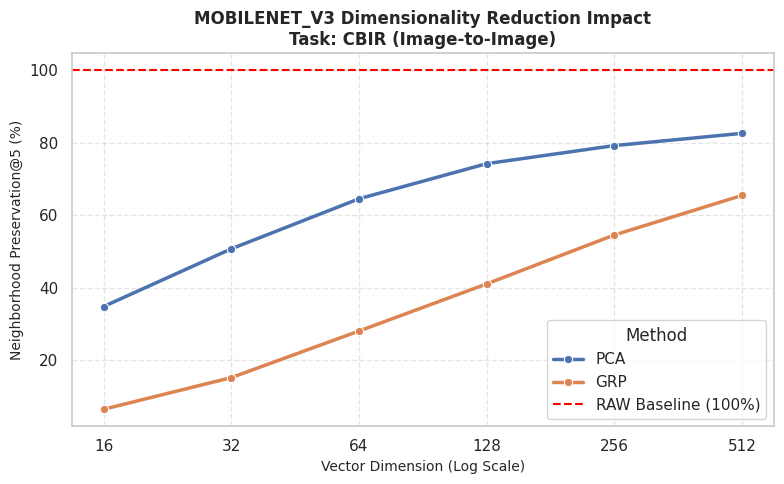


--- Running Unified Pipeline for VIT (vision) ---
Loaded VISION | Model: vit | Shape: (2000, 768)
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_vit_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,vit,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.24,1.0x
1,vit,PCA,512,84.70,98.98,99.16,19.83,1.67,1.3x
2,vit,PCA,256,81.12,98.58,98.84,19.77,0.84,2.7x
3,vit,PCA,128,73.11,96.65,97.32,19.46,0.59,3.8x
4,vit,PCA,64,61.44,91.06,92.95,18.59,0.59,3.8x
5,vit,PCA,32,47.63,79.19,83.71,16.74,0.59,3.8x
6,vit,PCA,16,32.65,60.52,69.07,13.81,0.55,4.1x
7,vit,GRP,512,74.73,96.03,96.74,19.35,1.35,1.7x
8,vit,GRP,256,64.75,88.35,90.59,18.12,0.82,2.7x
9,vit,GRP,128,52.39,74.58,79.44,15.89,0.55,4.1x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,vit,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.24,1.0x
1,vit,PCA,512,84.70,98.98,99.16,19.83,1.67,1.3x
2,vit,PCA,256,81.12,98.58,98.84,19.77,0.84,2.7x
3,vit,PCA,128,73.11,96.65,97.32,19.46,0.59,3.8x
4,vit,PCA,64,61.44,91.06,92.95,18.59,0.59,3.8x
5,vit,PCA,32,47.63,79.19,83.71,16.74,0.59,3.8x
6,vit,PCA,16,32.65,60.52,69.07,13.81,0.55,4.1x
7,vit,GRP,512,74.73,96.03,96.74,19.35,1.35,1.7x
8,vit,GRP,256,64.75,88.35,90.59,18.12,0.82,2.7x
9,vit,GRP,128,52.39,74.58,79.44,15.89,0.55,4.1x


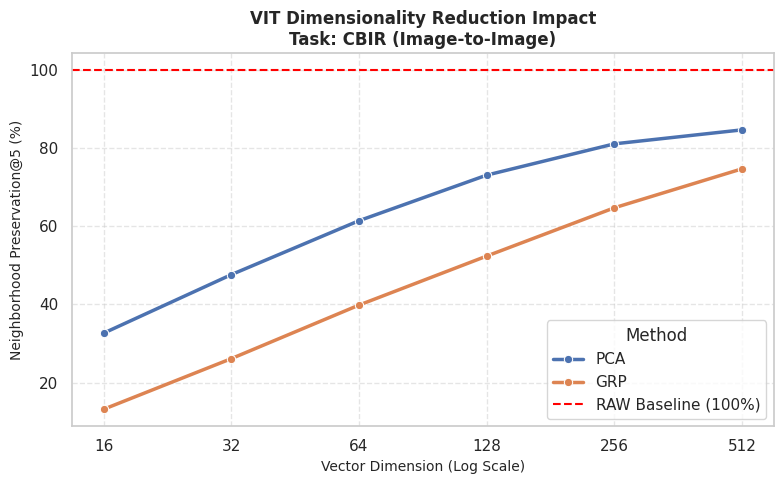


--- Running Unified Pipeline for DEIT (vision) ---
Loaded VISION | Model: deit | Shape: (2000, 768)
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_deit_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,deit,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.08,1.0x
1,deit,PCA,512,91.29,99.94,99.96,19.99,1.77,1.2x
2,deit,PCA,256,85.25,99.73,99.79,19.96,0.94,2.2x
3,deit,PCA,128,74.67,98.48,98.77,19.75,0.59,3.5x
4,deit,PCA,64,61.66,93.45,94.94,18.99,0.64,3.3x
5,deit,PCA,32,45.93,80.26,84.96,16.99,0.59,3.5x
6,deit,PCA,16,30.59,58.59,67.80,13.56,0.53,3.9x
7,deit,GRP,512,68.44,95.17,96.10,19.22,1.34,1.6x
8,deit,GRP,256,59.02,86.67,89.48,17.89,0.83,2.5x
9,deit,GRP,128,44.28,67.84,74.30,14.86,0.55,3.8x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,deit,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.08,1.0x
1,deit,PCA,512,91.29,99.94,99.96,19.99,1.77,1.2x
2,deit,PCA,256,85.25,99.73,99.79,19.96,0.94,2.2x
3,deit,PCA,128,74.67,98.48,98.77,19.75,0.59,3.5x
4,deit,PCA,64,61.66,93.45,94.94,18.99,0.64,3.3x
5,deit,PCA,32,45.93,80.26,84.96,16.99,0.59,3.5x
6,deit,PCA,16,30.59,58.59,67.80,13.56,0.53,3.9x
7,deit,GRP,512,68.44,95.17,96.10,19.22,1.34,1.6x
8,deit,GRP,256,59.02,86.67,89.48,17.89,0.83,2.5x
9,deit,GRP,128,44.28,67.84,74.30,14.86,0.55,3.8x


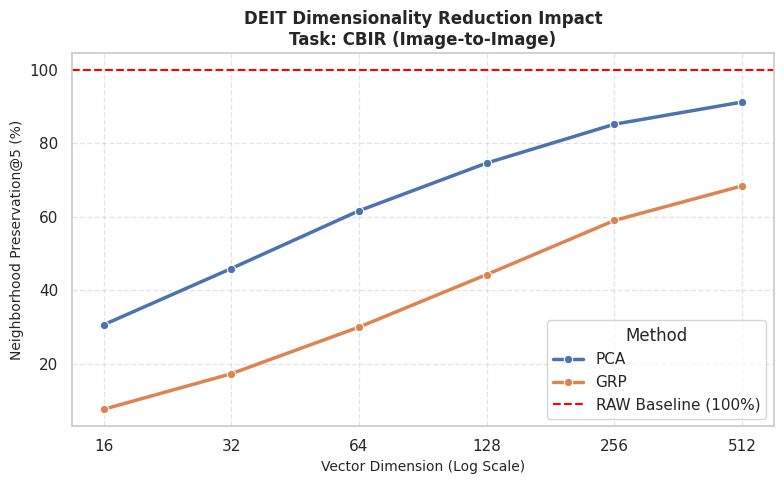


--- Running Unified Pipeline for CLIP_VISION (vision) ---
Loaded VISION | Model: clip_vision | Shape: (2000, 768)
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_vision_clip_vision_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,clip_vision,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.11,1.0x
1,clip_vision,PCA,512,80.12,98.88,99.10,19.82,1.77,1.2x
2,clip_vision,PCA,256,78.33,98.61,98.89,19.78,1.05,2.0x
3,clip_vision,PCA,128,73.57,97.50,98.03,19.60,0.70,3.0x
4,clip_vision,PCA,64,64.71,94.38,95.65,19.13,0.59,3.5x
5,clip_vision,PCA,32,53.21,87.58,90.66,18.13,0.58,3.6x
6,clip_vision,PCA,16,38.93,73.39,80.20,16.04,0.55,3.8x
7,clip_vision,GRP,512,73.45,98.96,99.17,19.83,1.35,1.6x
8,clip_vision,GRP,256,63.68,95.10,96.14,19.23,0.82,2.6x
9,clip_vision,GRP,128,51.66,83.69,87.47,17.49,0.55,3.8x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,clip_vision,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.11,1.0x
1,clip_vision,PCA,512,80.12,98.88,99.10,19.82,1.77,1.2x
2,clip_vision,PCA,256,78.33,98.61,98.89,19.78,1.05,2.0x
3,clip_vision,PCA,128,73.57,97.50,98.03,19.60,0.70,3.0x
4,clip_vision,PCA,64,64.71,94.38,95.65,19.13,0.59,3.5x
5,clip_vision,PCA,32,53.21,87.58,90.66,18.13,0.58,3.6x
6,clip_vision,PCA,16,38.93,73.39,80.20,16.04,0.55,3.8x
7,clip_vision,GRP,512,73.45,98.96,99.17,19.83,1.35,1.6x
8,clip_vision,GRP,256,63.68,95.10,96.14,19.23,0.82,2.6x
9,clip_vision,GRP,128,51.66,83.69,87.47,17.49,0.55,3.8x


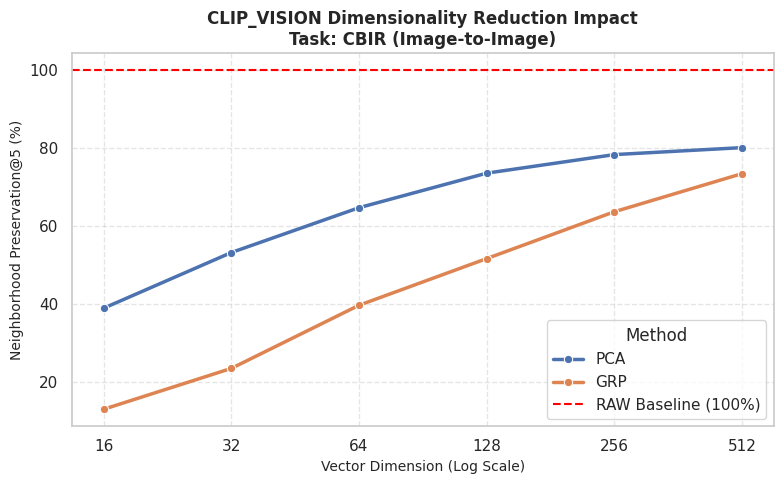


Generating Subplot Grid for VISION models...


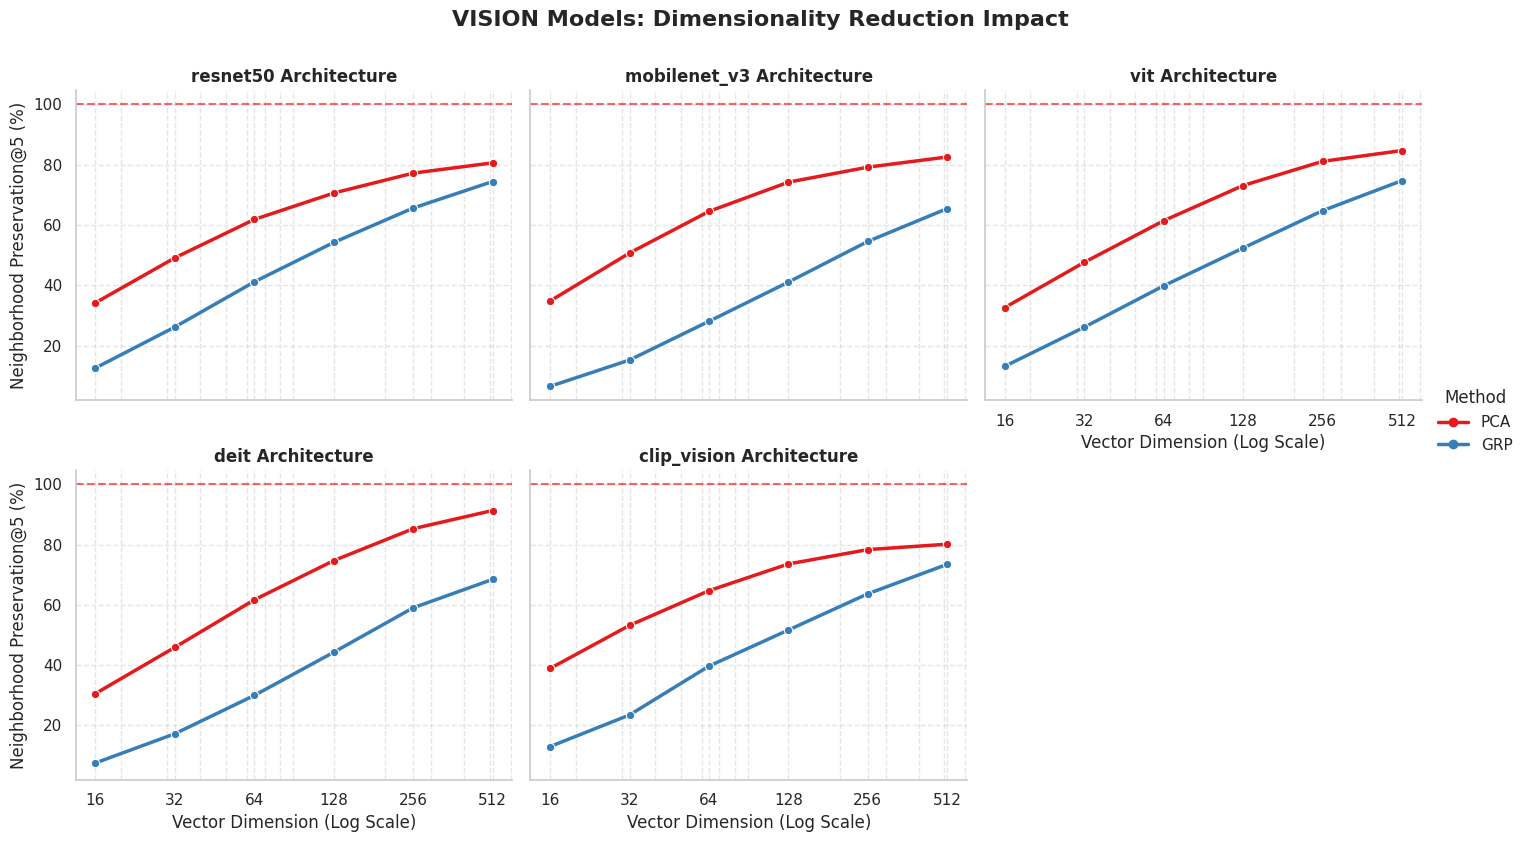

In [40]:
all_results = []
vision_results = [] # Store just the vision dataframes

# --- 1. RUN VISION MODELS (CBIR) ---
print("="*50 + "\nSTARTING VISION (CBIR) EVALUATIONS\n" + "="*50)
for v_model in VISION_MODELS:
    try:
        # Call the new unified function (which SAVES the .npy files!)
        df_res = run_experiment("vision", v_model)
        
        # Save CSV and Plot
        df_res.to_csv(os.path.join(DATA_DIR, f"results_unimodal_vision_{v_model}.csv"), index=False)
        display(df_res)
        plot_unimodal_results(df_res, "vision", v_model)
        
        all_results.append(df_res)
        vision_results.append(df_res)
        
        # Ping your phone
        requests.post(f"https://ntfy.sh/{topic_name}", data=f"✅ Vision Model {v_model} complete!".encode('utf-8'))
        
    except FileNotFoundError as e:
        print(f"⚠️ Skipping {v_model}: {e}")

if vision_results:
    vision_master_df = pd.concat(vision_results, ignore_index=True)
    plot_unimodal_grid(vision_master_df, "vision")



STARTING TEXT EVALUATIONS

--- Running Unified Pipeline for RNN (text) ---
Loaded TEXT | Model: rnn | Shape: (2000, 768)


Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_rnn_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,rnn,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.06,1.0x
1,rnn,PCA,512,79.17,95.04,96.01,19.20,1.33,1.5x
2,rnn,PCA,256,78.38,94.98,95.93,19.18,0.85,2.4x
3,rnn,PCA,128,71.27,94.44,95.48,19.09,0.64,3.2x
4,rnn,PCA,64,57.77,89.80,91.82,18.36,0.56,3.7x
5,rnn,PCA,32,43.07,77.52,82.49,16.50,0.53,3.9x
6,rnn,PCA,16,28.94,59.94,68.42,13.68,0.50,4.1x
7,rnn,GRP,512,75.57,98.68,98.91,19.78,1.34,1.5x
8,rnn,GRP,256,67.92,95.09,96.11,19.22,0.83,2.5x
9,rnn,GRP,128,58.03,88.52,90.88,18.18,0.55,3.7x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,rnn,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.06,1.0x
1,rnn,PCA,512,79.17,95.04,96.01,19.20,1.33,1.5x
2,rnn,PCA,256,78.38,94.98,95.93,19.18,0.85,2.4x
3,rnn,PCA,128,71.27,94.44,95.48,19.09,0.64,3.2x
4,rnn,PCA,64,57.77,89.80,91.82,18.36,0.56,3.7x
5,rnn,PCA,32,43.07,77.52,82.49,16.50,0.53,3.9x
6,rnn,PCA,16,28.94,59.94,68.42,13.68,0.50,4.1x
7,rnn,GRP,512,75.57,98.68,98.91,19.78,1.34,1.5x
8,rnn,GRP,256,67.92,95.09,96.11,19.22,0.83,2.5x
9,rnn,GRP,128,58.03,88.52,90.88,18.18,0.55,3.7x


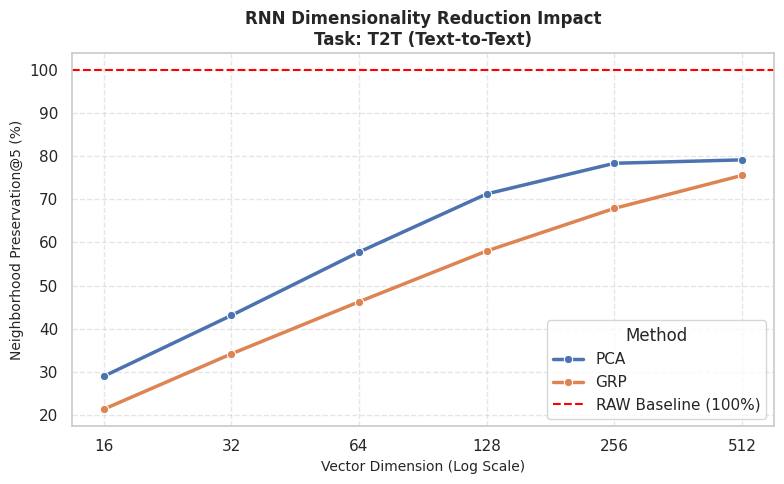


--- Running Unified Pipeline for BERT (text) ---
Loaded TEXT | Model: bert | Shape: (2000, 768)
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_bert_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,bert,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.05,1.0x
1,bert,PCA,512,54.77,74.33,80.38,16.08,1.37,1.5x
2,bert,PCA,256,54.99,74.59,80.62,16.12,0.88,2.3x
3,bert,PCA,128,55.45,75.10,81.05,16.21,0.54,3.8x
4,bert,PCA,64,55.93,75.79,81.53,16.31,0.65,3.2x
5,bert,PCA,32,55.97,76.95,82.37,16.47,0.50,4.1x
6,bert,PCA,16,53.02,78.09,83.34,16.67,0.56,3.7x
7,bert,GRP,512,83.84,99.99,99.99,20.00,1.34,1.5x
8,bert,GRP,256,78.82,99.96,99.97,19.99,0.84,2.4x
9,bert,GRP,128,70.54,99.36,99.46,19.89,0.57,3.6x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,bert,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.05,1.0x
1,bert,PCA,512,54.77,74.33,80.38,16.08,1.37,1.5x
2,bert,PCA,256,54.99,74.59,80.62,16.12,0.88,2.3x
3,bert,PCA,128,55.45,75.10,81.05,16.21,0.54,3.8x
4,bert,PCA,64,55.93,75.79,81.53,16.31,0.65,3.2x
5,bert,PCA,32,55.97,76.95,82.37,16.47,0.50,4.1x
6,bert,PCA,16,53.02,78.09,83.34,16.67,0.56,3.7x
7,bert,GRP,512,83.84,99.99,99.99,20.00,1.34,1.5x
8,bert,GRP,256,78.82,99.96,99.97,19.99,0.84,2.4x
9,bert,GRP,128,70.54,99.36,99.46,19.89,0.57,3.6x


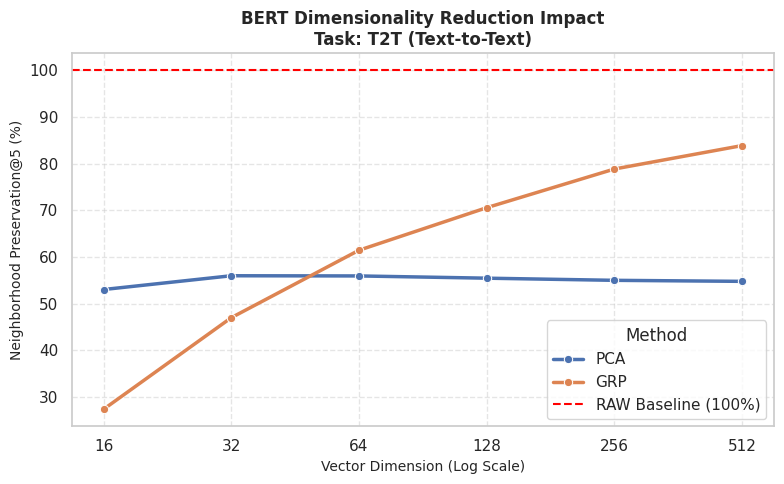


--- Running Unified Pipeline for ROBERTA (text) ---
Loaded TEXT | Model: roberta | Shape: (2000, 768)
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_roberta_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,roberta,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.11,1.0x
1,roberta,PCA,512,62.29,86.06,89.39,17.88,1.73,1.2x
2,roberta,PCA,256,62.25,86.13,89.44,17.89,0.89,2.4x
3,roberta,PCA,128,61.95,85.80,89.24,17.85,0.55,3.9x
4,roberta,PCA,64,59.32,84.26,88.08,17.62,0.63,3.4x
5,roberta,PCA,32,52.75,79.87,85.01,17.00,0.35,6.0x
6,roberta,PCA,16,39.64,67.33,75.62,15.12,0.54,3.9x
7,roberta,GRP,512,79.57,99.84,99.86,19.97,1.32,1.6x
8,roberta,GRP,256,72.38,98.91,99.12,19.82,0.91,2.3x
9,roberta,GRP,128,62.93,95.26,96.34,19.27,0.55,3.8x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,roberta,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.11,1.0x
1,roberta,PCA,512,62.29,86.06,89.39,17.88,1.73,1.2x
2,roberta,PCA,256,62.25,86.13,89.44,17.89,0.89,2.4x
3,roberta,PCA,128,61.95,85.80,89.24,17.85,0.55,3.9x
4,roberta,PCA,64,59.32,84.26,88.08,17.62,0.63,3.4x
5,roberta,PCA,32,52.75,79.87,85.01,17.00,0.35,6.0x
6,roberta,PCA,16,39.64,67.33,75.62,15.12,0.54,3.9x
7,roberta,GRP,512,79.57,99.84,99.86,19.97,1.32,1.6x
8,roberta,GRP,256,72.38,98.91,99.12,19.82,0.91,2.3x
9,roberta,GRP,128,62.93,95.26,96.34,19.27,0.55,3.8x


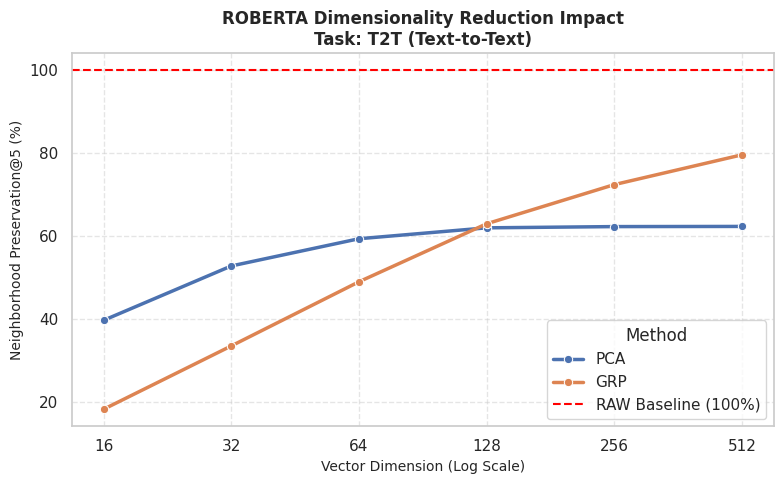


--- Running Unified Pipeline for GPT2 (text) ---
Loaded TEXT | Model: gpt2 | Shape: (2000, 768)
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_pca_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_pca_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_pca_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_pca_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_pca_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_pca_16_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_grp_512_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_grp_256_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_grp_128_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_grp_64_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_grp_32_Flickr8k.npy
Saved: /home/aysel/tfe/TFE_Data/X_text_gpt2_grp_16_Flickr8k.npy


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,gpt2,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.14,1.0x
1,gpt2,PCA,512,33.98,63.89,71.90,14.38,1.61,1.3x
2,gpt2,PCA,256,33.94,64.21,72.20,14.44,0.83,2.6x
3,gpt2,PCA,128,34.01,64.60,72.51,14.50,0.67,3.2x
4,gpt2,PCA,64,34.22,65.29,73.11,14.62,0.65,3.3x
5,gpt2,PCA,32,33.91,66.03,73.72,14.74,0.55,3.9x
6,gpt2,PCA,16,31.80,66.72,74.19,14.84,0.46,4.7x
7,gpt2,GRP,512,83.26,100.00,100.00,20.00,1.44,1.5x
8,gpt2,GRP,256,79.16,99.98,99.98,20.00,0.83,2.6x
9,gpt2,GRP,128,70.18,99.37,99.51,19.90,0.55,3.9x


,Model,Method,Dim,Preservation@5,mAP@10,Prec@10,Rec@10,Time (ms),Speedup
0,gpt2,RAW (Baseline),768,100.00,100.00,100.00,100.00,2.14,1.0x
1,gpt2,PCA,512,33.98,63.89,71.90,14.38,1.61,1.3x
2,gpt2,PCA,256,33.94,64.21,72.20,14.44,0.83,2.6x
3,gpt2,PCA,128,34.01,64.60,72.51,14.50,0.67,3.2x
4,gpt2,PCA,64,34.22,65.29,73.11,14.62,0.65,3.3x
5,gpt2,PCA,32,33.91,66.03,73.72,14.74,0.55,3.9x
6,gpt2,PCA,16,31.80,66.72,74.19,14.84,0.46,4.7x
7,gpt2,GRP,512,83.26,100.00,100.00,20.00,1.44,1.5x
8,gpt2,GRP,256,79.16,99.98,99.98,20.00,0.83,2.6x
9,gpt2,GRP,128,70.18,99.37,99.51,19.90,0.55,3.9x


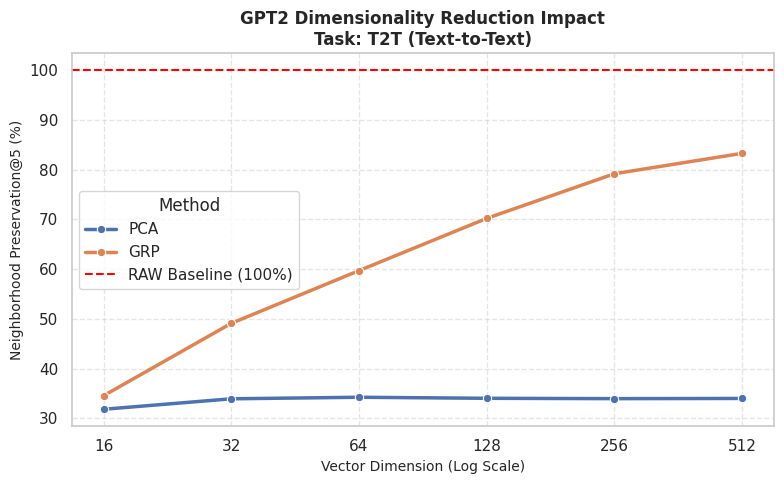


--- Running Unified Pipeline for CLIP_TEXT (text) ---
Loaded TEXT | Model: clip_text | Shape: (2000, 512)


In [ ]:
text_results = []

# --- 2. RUN TEXT MODELS (NLP) ---
print("\n" + "="*50 + "\nSTARTING TEXT EVALUATIONS\n" + "="*50)
for t_model in TEXT_MODELS:
    try:
        df_res = run_experiment("text", t_model)
        
        df_res.to_csv(os.path.join(DATA_DIR, f"results_unimodal_text_{t_model}.csv"), index=False)
        display(df_res)
        plot_unimodal_results(df_res, "text", t_model)
        
        all_results.append(df_res)
        text_results.append(df_res)
        requests.post(f"https://ntfy.sh/{topic_name}", data=f"✅ Text Model {t_model} complete!".encode('utf-8'))
        
    except FileNotFoundError as e:
        print(f"⚠️ Skipping {t_model}: {e}")

if text_results:
    text_master_df = pd.concat(text_results, ignore_index=True)
    plot_unimodal_grid(text_master_df, "text")


In [35]:

# --- 3. SAVE THE MASTER THESIS RESULTS ---
print("\n" + "="*50 + "\nCOMPILING MASTER RESULTS\n" + "="*50)
if all_results:
    final_master_df = pd.concat(all_results, ignore_index=True)
    master_csv_path = os.path.join(DATA_DIR, "MASTER_THESIS_RESULTS.csv")
    final_master_df.to_csv(master_csv_path, index=False)
    
    print(f"🎉 All experiments complete! Master table saved to {master_csv_path}")
    requests.post(f"https://ntfy.sh/{topic_name}", data="🎉 PHASE 1 COMPLETE! All matrices saved.".encode('utf-8'))


COMPILING MASTER RESULTS
🎉 All experiments complete! Master table saved to /home/aysel/tfe/TFE_Data/MASTER_THESIS_RESULTS.csv


Generating Master Comparison for VISION models using PCA...


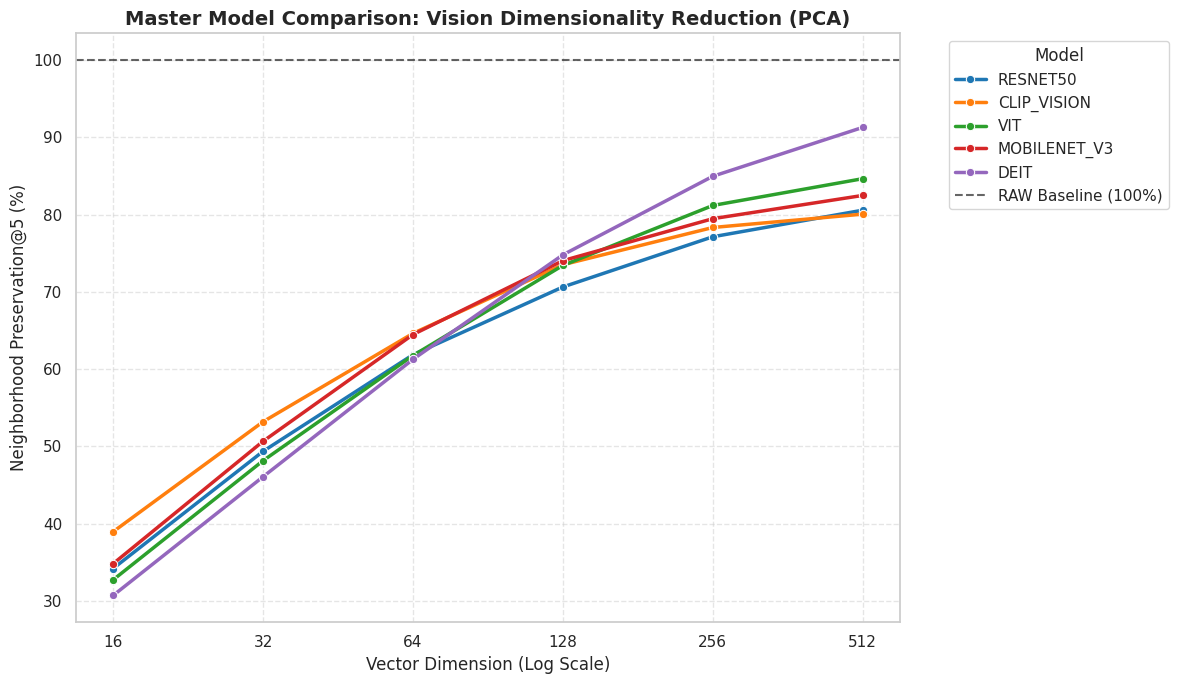

Generating Master Comparison for TEXT models using PCA...


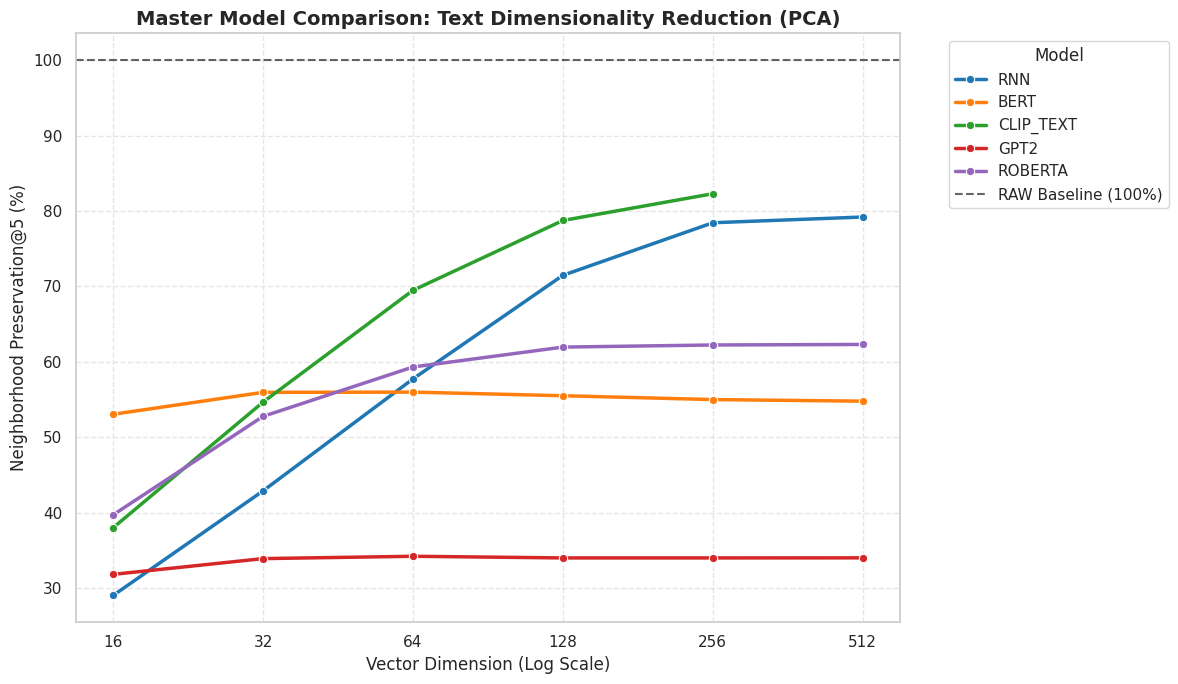

In [37]:
def generate_master_comparison(modality, method_filter="PCA"):
    """Loads all unimodal results for a modality and plots them together."""
    print(f"Generating Master Comparison for {modality.upper()} models using {method_filter}...")
    
    # 1. Find all CSVs for this modality
    csv_files = glob.glob(os.path.join(DATA_DIR, f"results_unimodal_{modality}_*.csv"))
    
    if not csv_files:
        print(f"No CSVs found for {modality}.")
        return
        
    # 2. Combine them into one giant DataFrame
    all_data = []
    for file in csv_files:
        model_name = file.split(f"results_unimodal_{modality}_")[1].replace(".csv", "")
        df = pd.read_csv(file)
        df["Model"] = model_name.upper()
        all_data.append(df)
        
    master_df = pd.concat(all_data, ignore_index=True)
    
    # 3. Filter for just PCA (and exclude the RAW baseline to see the pure curves)
    plot_df = master_df[(master_df["Method"] == method_filter) & (master_df["Method"] != "RAW (Baseline)")]
    
    # 4. Plot the Master Graph
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=plot_df, x="Dim", y="Preservation@5", hue="Model", marker="o", linewidth=2.5, palette="tab10")

    
    plt.axhline(y=100.0, color='black', linestyle='--', label='RAW Baseline (100%)', alpha=0.6)
    
    plt.title(f"Master Model Comparison: {modality.capitalize()} Dimensionality Reduction ({method_filter})", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Vector Dimension (Log Scale)", fontsize=12)
    plt.ylabel("Neighborhood Preservation@5 (%)", fontsize=12)
    plt.xscale('log', base=2)
    
    # Get dimensions dynamically from the dataframe
    dims = sorted(plot_df["Dim"].unique())
    plt.xticks(dims, labels=dims)
    
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    
    # Save the master plot
    plt.savefig(os.path.join(DATA_DIR, f"plot_master_comparison_{modality}_{method_filter}.png"), dpi=300)
    plt.show()

# Run it for both modalities!
generate_master_comparison("vision", "PCA")
generate_master_comparison("text", "PCA")